# Week 5 - Exercises

## Exercise 1: Law of large numbers

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# step 1: sample 10000 points from gaussian with mu=0 and sigma=4
np.random.seed(42)
N = 10_000
X = np.random.standard_normal(N) * 4 # scale by sigma=4

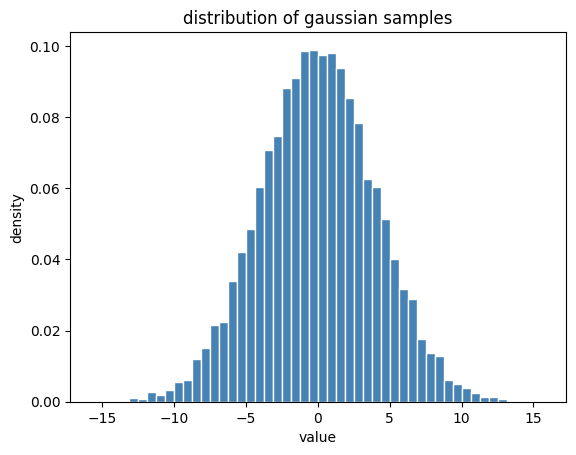

In [5]:
# step 2: plot distribution of X
fig, ax = plt.subplots()
ax.hist(X, bins=50, density=True, color='steelblue', edgecolor='white')
ax.set_xlabel('value')
ax.set_ylabel('density')
ax.set_title('distribution of gaussian samples')
plt.show()

In [6]:
# step 3: cumulative average
cumulative_avg = np.cumsum(X) / np.arange(1, N + 1)

# step 4: cumulative standard error (sigma / sqrt(n))
cumulative_std = np.array([X[:1].std() for i in range(1, N + 1)])
cumulative_se = cumulative_std / np.sqrt(np.arange(1, N + 1))

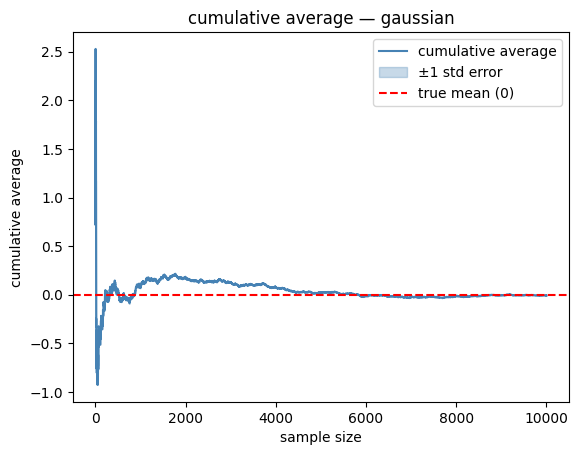

In [ ]:
# step 5: true mean and median of gaussian (both equal mu=0 for a gaussian)
true_mean = 0
true_median = 0

# step 6: plot cumulative average with error bars and true mean line
fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_avg, color='steelblue', label='cumulative average')
ax.fill_between(np.arange(1, N + 1),
                cumulative_avg - cumulative_se,
                cumulative_avg + cumulative_se,
                alpha=0.3, color='steelblue', label='±1 std error')
ax.axhline(true_mean, color='red', linestyle='--', label='true mean (0)')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative average')
ax.set_title('cumulative average, gaussian')
ax.legend()
plt.show()

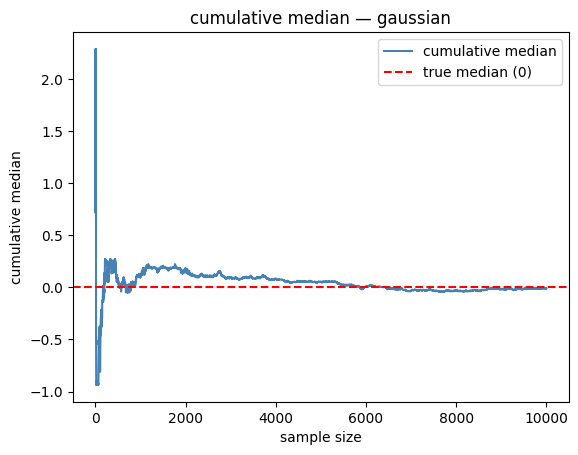

In [ ]:
# step 7: cumulative median
cumulative_med = np.array([np.median(X[:i]) for i in range(1, N + 1)])

# step 8: plot cumulative median
fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_med, color='steelblue', label='cumulative median')
ax.axhline(true_median, color='red', linestyle='--', label='true median (0)')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative median')
ax.set_title('cumulative median, gaussian')
ax.legend()
plt.show()

In [9]:
# step 9: sample 10,000 points from pareto with alpha=0.5
X_pareto = np.random.pareto(0.5, N) + 1  # +1 to shift so x_m=1

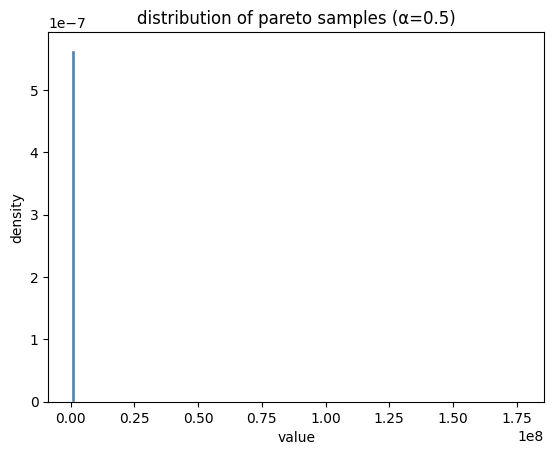

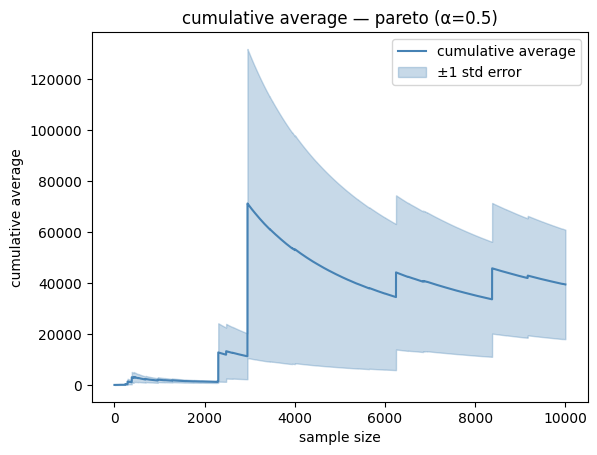

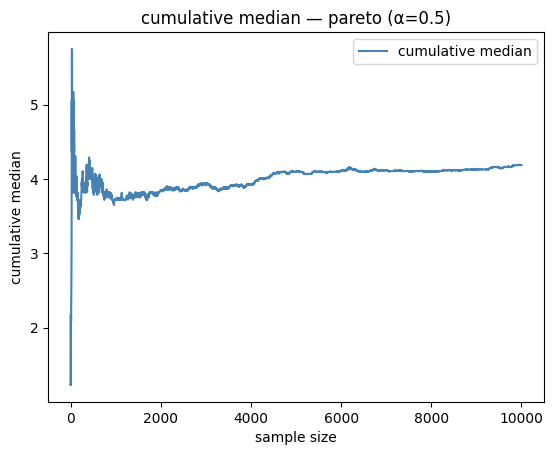

In [ ]:
# distribution
fig, ax = plt.subplots()
ax.hist(X_pareto, bins=100, density=True, color='steelblue', edgecolor='white')
ax.set_xlabel('value')
ax.set_ylabel('density')
ax.set_title('distribution of pareto samples (α=0.5)')
plt.show()

# cumulative average
cumulative_avg_p = np.cumsum(X_pareto) / np.arange(1, N + 1)
cumulative_std_p = np.array([X_pareto[:i].std() for i in range(1, N + 1)])
cumulative_se_p = cumulative_std_p / np.sqrt(np.arange(1, N + 1))

fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_avg_p, color='steelblue', label='cumulative average')
ax.fill_between(np.arange(1, N + 1),
                cumulative_avg_p - cumulative_se_p,
                cumulative_avg_p + cumulative_se_p,
                alpha=0.3, color='steelblue', label='±1 std error')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative average')
ax.set_title('cumulative average, pareto (α=0.5)')
ax.legend()
plt.show()

# cumulative median
cumulative_med_p = np.array([np.median(X_pareto[:i]) for i in range(1, N + 1)])

fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_med_p, color='steelblue', label='cumulative median')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative median')
ax.set_title('cumulative median, pareto (α=0.5)')
ax.legend()
plt.show()

In [11]:
import json

# step 11: load papers and get citation counts
with open('week3_css_papers.json', 'r') as f:
    papers = json.load(f)

citations = np.array([p['cited_by_count'] for p in papers])

# population mean and median
pop_mean = np.mean(citations)
pop_median = np.median(citations)
print(f'population mean citations: {pop_mean:.2f}')
print(f'population median citations: {pop_median:.2f}')

# random sample of 10,000
sample = np.random.choice(citations, size=10_000, replace=False)

population mean citations: 107.82
population median citations: 40.00


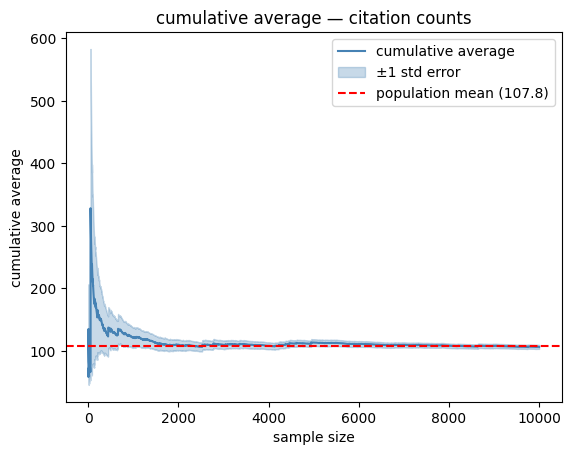

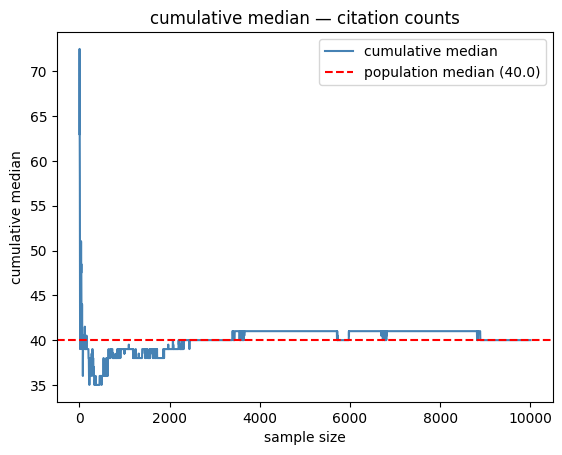

In [ ]:
# cumulative average
cumulative_avg_c = np.cumsum(sample) / np.arange(1, N + 1)
cumulative_std_c = np.array([sample[:i].std() for i in range(1, N + 1)])
cumulative_se_c = cumulative_std_c / np.sqrt(np.arange(1, N + 1))

fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_avg_c, color='steelblue', label='cumulative average')
ax.fill_between(np.arange(1, N + 1),
                cumulative_avg_c - cumulative_se_c,
                cumulative_avg_c + cumulative_se_c,
                alpha=0.3, color='steelblue', label='±1 std error')
ax.axhline(pop_mean, color='red', linestyle='--', label=f'population mean ({pop_mean:.1f})')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative average')
ax.set_title('cumulative average, citation counts')
ax.legend()
plt.show()

# cumulative median
cumulative_med_c = np.array([np.median(sample[:i]) for i in range(1, N + 1)])

fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), cumulative_med_c, color='steelblue', label='cumulative median')
ax.axhline(pop_median, color='red', linestyle='--', label=f'population median ({pop_median:.1f})')
ax.set_xlabel('sample size')
ax.set_ylabel('cumulative median')
ax.set_title('cumulative median, citation counts')
ax.legend()
plt.show()

### Reflections

**Q1: Compare the cumulative average for Gaussian vs Pareto distributions.**

For the gaussian, the cumulative average converges quickly and smoothly to the 
true mean (0), with the error band shrinking steadily as sample size grows. This 
matches expectations, the gaussian has a finite mean and variance, so the law 
of large numbers kicks in fast. For the pareto (α=0.5), the average never 
stabilizes. Each time an extreme outlier is sampled, the average jumps dramatically 
and the error band explodes. This is because α=0.5 gives the pareto an infinite 
theoretical mean, so there is simply nothing for the average to converge to.

**Q2: Cumulative median vs cumulative average, which is more useful?**

Across both distributions, the median consistently outperforms the mean as a 
summary statistic. For the gaussian, both converge similarly since the distribution 
is symmetric. But for the pareto, the median converges smoothly to a stable value 
while the mean diverges. The median is robust to extreme outliers because it only 
cares about the middle value, not the magnitude of the extremes. This makes it 
a far more reliable statistic when dealing with heavy-tailed data.

**Q3: What does the citation data tell us?**

The citation data shows a clear heavy-tail signature: the population mean (107.8) 
is more than 2.5× the median (40.0), indicating that a small number of highly-cited 
papers pull the mean upward. The cumulative average is noisy early on and takes 
thousands of samples to stabilize, while the cumulative median converges quickly. 
This implies that using mean citations as a measure of typical impact is misleading,
most papers have far fewer citations than the mean suggests.

**Q4: Key takeaways**

When data is heavy-tailed, the mean is an unreliable and potentially misleading 
summary statistic. The median is more robust and better represents the typical 
value. Since many real-world social datasets, citations, wealth, followers, 
degrees in networks, follow heavy-tailed distributions, this has broad implications 
for how we summarize and interpret data in computational social science.

## Exercise 2: Did you really read the text?

**Q1: What's the problem with random networks as a model for real-world networks 
(section 3.5)?**

Random networks predict a poisson degree distribution, meaning most nodes have roughly the same degree close to the average, and extremely high-degree nodes are essentially impossible. But real-world networks consistently contain hubs, nodes with far more connections than the average. Since the poisson distribution has an exponentially decaying tail, it cannot produce these hubs, making random networks a poor model for real social networks.

**Q2: List the four regimes of random networks as a function of ⟨k⟩.**

1. Subcritical (⟨k⟩ < 1): The network consists of small isolated clusters with 
no giant component.
2. Critical (⟨k⟩ = 1): A giant component just begins to emerge, containing on 
the order of N^(2/3) nodes.
3. Supercritical (⟨k⟩ > 1): A giant component exists and grows with N, while 
smaller clusters remain.
4. Connected (⟨k⟩ ≥ ln N): Virtually all nodes belong to a single giant connected 
component.

**Q3: Why is degree-dependent clustering C(k) a problem for random networks?**

In real-world networks, the clustering coefficient C(k) decreases as node degree k increases, high-degree hubs tend to connect disparate groups and therefore have low local clustering, while low-degree nodes tend to form tight cliques. In random networks, clustering is degree-independent: Every node has roughly the same clustering coefficient regardless of how many connections it has. This means random networks cannot reproduce one of the most fundamental structural patterns in real social networks, further limiting their usefulness as a model.

## Exercise 3: Analyzing Networks through a Random Model

In [13]:
import networkx as nx
import json

# load the network we built in week 4
with open('week4_css_network.json', 'r') as f:
    network_data = json.load(f)

# rebuild the graph
G = nx.node_link_graph(network_data)

print(f'nodes: {G.number_of_nodes()}')
print(f'edges: {G.number_of_edges()}')

nodes: 18307
edges: 73938


In [15]:
# calculate p and average degree
N_real = G.number_of_nodes()
L_real = G.number_of_edges()

# p = L / L_max, where L_max = N*(N-1)/2
L_max = N_real * (N_real - 1) / 2
p = L_real / L_max

# average degree = p * (N-1)
avg_degree = p * (N_real - 1)

print(f'p = {p:.6f}')
print(f'average degree ⟨k⟩ = {avg_degree:.4f}')
print(f'ln(N) = {np.log(N_real):.4f}')
print(f'regime: ⟨k⟩ > 1? {avg_degree > 1} | ⟨k⟩ > ln(N)? {avg_degree > np.log(N_real)}')

p = 0.000441
average degree ⟨k⟩ = 8.0776
ln(N) = 9.8150
regime: ⟨k⟩ > 1? True | ⟨k⟩ > ln(N)? False


In [17]:
# build random network with same N and p
def generate_random_network(N, p):
    G_random = nx.Graph()
    G_random.add_nodes_from(range(N))
    for i in range(N):
        for j in range(i + 1, N):
            if np.random.uniform() < p:
                G_random.add_edge(i, j)
    return G_random

print('generating random network')
G_random = generate_random_network(N_real, p)
print(f'random network nodes: {G_random.number_of_nodes()}')
print(f'random network edges: {G_random.number_of_edges()}')

generating random network
random network nodes: 18307
random network edges: 73803


In [24]:
network, config = nw.visualize(G_random)

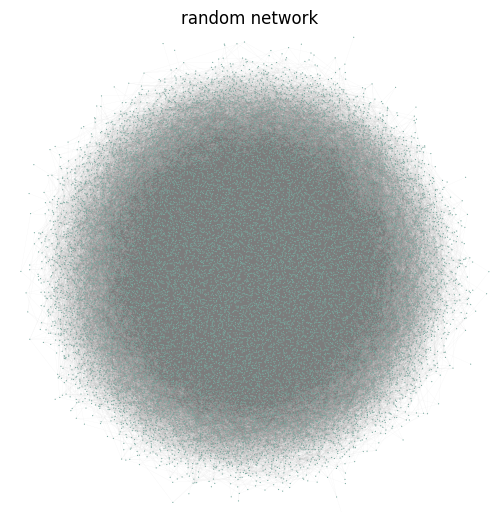

In [25]:
from netwulf import draw_netwulf

fig, ax = draw_netwulf(network, config)
ax.set_title('random network')
plt.savefig('week5_random_network.png', dpi=150, bbox_inches='tight')
plt.show()

**What regime does the random network fall into?**

with ⟨k⟩ = 8.08, the network is in the supercritical regime (⟨k⟩ > 1 but 
⟨k⟩ < ln(N) = 9.81). a giant component exists but the network is not yet 
fully connected, some smaller isolated components remain.

**What does the network structure resemble in this regime?**

according to the textbook, in the supercritical regime a giant component 
emerges that contains a significant fraction of all nodes, while the remaining 
nodes form small isolated clusters. the giant component grows as ⟨k⟩ increases.

**Key differences between the real and random networks.**

the most visible difference is in degree distribution: the real CSS network 
contains hubs, a small number of researchers with far more collaborations 
than average, which would never appear in a random network of the same size. 
the random network produces a poisson-like distribution where most nodes have 
degree close to ⟨k⟩. additionally, the real network is expected to show 
higher clustering and community structure, reflecting the fact that researchers 
in the same subfield tend to collaborate with each other. these differences 
are consistent with theoretical expectations, as random networks are known to 
fail at reproducing hubs and high clustering.

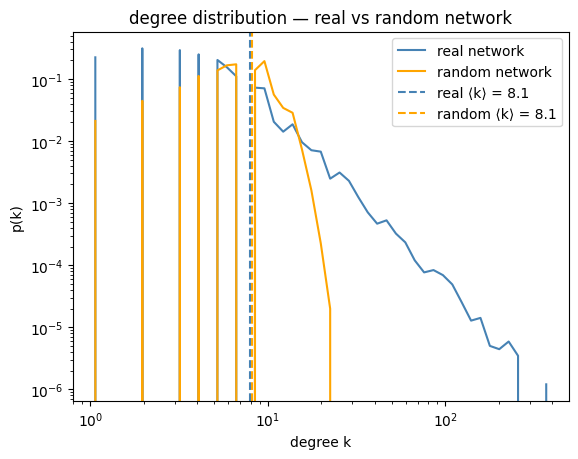

In [ ]:
# exercise 3.2: degree distributions
real_degrees = [d for _, d in G.degree()]
random_degrees = [d for _, d in G_random.degree()]

bins = np.logspace(np.log10(1), np.log10(max(real_degrees)), 50)

real_counts, real_bins = np.histogram(real_degrees, bins=bins, density=True)
random_counts, random_bins = np.histogram(random_degrees, bins=bins, density=True)

bin_centers_real = (real_bins[:-1] + real_bins[1:]) / 2
bin_centers_random = (random_bins[:-1] + random_bins[1:]) / 2

avg_real = np.mean(real_degrees)
avg_random = np.mean(random_degrees)

fig, ax = plt.subplots()
ax.plot(bin_centers_real, real_counts, color='steelblue', label='real network')
ax.plot(bin_centers_random, random_counts, color='orange', label='random network')
ax.axvline(avg_real - 0.1, color='steelblue', linestyle='--', label=f'real ⟨k⟩ = {avg_real:.1f}')
ax.axvline(avg_random + 0.1, color='orange', linestyle='--', label=f'random ⟨k⟩ = {avg_random:.1f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('degree k')
ax.set_ylabel('p(k)')
ax.set_title('degree distribution, real vs random network')
ax.legend()
plt.show()

**Does average degree meaningfully represent the network?**

for the random network, the average degree is a reasonable summary, the 
distribution is narrow and peaked around ⟨k⟩, so most nodes are close to 
average. but for the real CSS network, the average is misleading. as we saw 
in exercise 1, heavy-tailed distributions make the mean a poor representative 
of the typical value. most researchers have far fewer than 8 collaborations, 
while a small number of hubs have hundreds. the average is pulled upward by 
these outliers and does not reflect the typical researcher's experience.

**What differences can you observe between the two distributions?**

the random network has a narrow, poisson-like distribution tightly concentrated 
around ⟨k⟩ = 8.1, with virtually no nodes above degree ~15. the real network 
has a broad heavy-tailed distribution, most nodes have low degree, but a small 
number of hubs have degree well above 100. this heavy tail is completely absent 
in the random network and reflects the presence of highly connected researchers 
who act as bridges across the collaboration network.

In [28]:
# exercise 3.3: find giant component of real network
components = nx.algorithms.connected_components(G)
largest_component = max(components, key=len)
G_giant = G.subgraph(largest_component)

print(f'giant component nodes: {G_giant.number_of_nodes()}')
print(f'giant component edges: {G_giant.number_of_edges()}')
print(f'fraction of total nodes: {G_giant.number_of_nodes() / G.number_of_nodes():.3f}')

giant component nodes: 17802
giant component edges: 72800
fraction of total nodes: 0.972


In [29]:
# giant component of random network
components_random = nx.algorithms.connected_components(G_random)
largest_component_random = max(components_random, key=len)
G_random_giant = G_random.subgraph(largest_component_random)

print(f'random giant component nodes: {G_random_giant.number_of_nodes()}')
print(f'random giant component edges: {G_random_giant.number_of_edges()}')
print(f'fraction of total nodes: {G_random_giant.number_of_nodes() / G_random.number_of_nodes():.3f}')

random giant component nodes: 18304
random giant component edges: 73803
fraction of total nodes: 1.000


In [30]:
print('calculating real network avg shortest path')
avg_spl_real = nx.average_shortest_path_length(G_giant)
print(f'real network avg shortest path: {avg_spl_real:.4f}')

print('calculating random network avg shortest path')
avg_spl_random = nx.average_shortest_path_length(G_random_giant)
print(f'random network avg shortest path: {avg_spl_random:.4f}')

print(f'theoretical ln(N)/ln(⟨k⟩): {np.log(N_real)/np.log(avg_degree):.4f}')

calculating real network avg shortest path
real network avg shortest path: 5.5150
calculating random network avg shortest path
random network avg shortest path: 4.9370
theoretical ln(N)/ln(⟨k⟩): 4.6982


**Why consider only the giant component?**

average shortest path length is only defined between nodes that are actually 
connected by a path. if we included isolated nodes or small disconnected 
components, the calculation would fail or be undefined. by restricting to the 
giant component we ensure all pairs of nodes are reachable from each other.

**Why use unweighted edges?**

edge weights in our network represent the number of co-authored papers between 
two researchers. using weighted shortest paths would measure something different,
the "cost" of traversing collaborations, rather than the number of hops 
between researchers. the small-world phenomenon is specifically about the number 
of steps needed to reach anyone in the network, so unweighted edges are the 
right choice.

**Does the CSS network exhibit the small-world phenomenon?**

yes. the real network has an average shortest path length of 5.52, meaning any 
two researchers in the giant component are on average only ~5.5 hops apart, 
despite the network containing over 17,000 nodes. this is very close to the 
random network (4.94) and the theoretical prediction of ln(N)/ln(⟨k⟩) = 4.70. 
this confirms the small-world property, the network is surprisingly compact. 
however, as established in exercises 3.1 and 3.2, the real network achieves 
this through a fundamentally different structure than a random network, with 
hubs and heavy-tailed degree distribution rather than uniform random wiring.